In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#cau 1 Đọc dữ liệu và hiển thị 5 dòng dữ liệu đầu tiên, 10 dòng dữ liệu cuối cùng
data = pd.read_csv('car_price_dataset.csv')
print("5 dòng dữ liệu đầu tiên:")
print(data.head())
print("\n10 dòng dữ liệu cuối cùng:")
print(data.tail(10))

5 dòng dữ liệu đầu tiên:
        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  

10 dòng dữ liệu cuối cùng:
           Brand     Model  Year  Engine_Size Fuel_Type    Transmission  \
9990        Audi        A3  2019          1.8  Electric          Manual   
9991    Mercedes   E-Class  2017          1.1    Diesel       Automatic   
9992         BMW  5 Series  2016          1.2    Hybrid      

In [7]:
#cau 2 Dữ liệu bao gồm những thuộc tính nào? Liệt kê theo nhóm các thuộc tính định
#tính, các thuộc tính định lượng và chọn tham số thống kê mô tả phù hợp để đo
#độ tập trung dữ liệu của mỗi nhóm.
qualitative = data.select_dtypes(include=['object']).columns.tolist()
quantitative = data.select_dtypes(exclude=['object']).columns.tolist()

print("\nThuộc tính định tính:", qualitative)
print("Thuộc tính định lượng:", quantitative)
print("\nThống kê mô tả cho thuộc tính định lượng:")
print(data[quantitative].describe())

print("\nThống kê mô tả cho thuộc tính định tính:")
print(data[qualitative].describe())


Thuộc tính định tính: ['Brand', 'Model', 'Fuel_Type', 'Transmission']
Thuộc tính định lượng: ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Price']

Thống kê mô tả cho thuộc tính định lượng:
               Year   Engine_Size        Mileage         Doors   Owner_Count  \
count  10000.000000  10000.000000   10000.000000  10000.000000  10000.000000   
mean    2011.543700      3.000560  149239.111800      3.497100      2.991100   
std        6.897699      1.149324   86322.348957      1.110097      1.422682   
min     2000.000000      1.000000      25.000000      2.000000      1.000000   
25%     2006.000000      2.000000   74649.250000      3.000000      2.000000   
50%     2012.000000      3.000000  149587.000000      3.000000      3.000000   
75%     2017.000000      4.000000  223577.500000      4.000000      4.000000   
max     2023.000000      5.000000  299947.000000      5.000000      5.000000   

             Price  
count  10000.00000  
mean    8852.96440  
std     311


Độ phân tán của giá xe:
count    10000.00000
mean      8852.96440
std       3112.59681
min       2000.00000
25%       6646.00000
50%       8858.50000
75%      11086.50000
max      18301.00000
Name: Price, dtype: float64


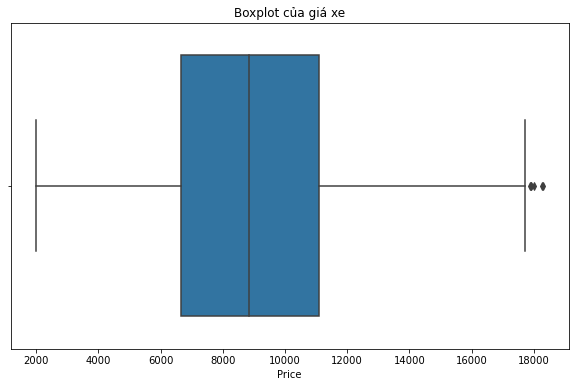

In [8]:
#cau 3 Tính các đặc trưng đo độ phân tán của giá xe và vẽ Boxplot.
print("\nĐộ phân tán của giá xe:")
print(data['Price'].describe())
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Price'])
plt.title("Boxplot của giá xe")
plt.show()

In [9]:
#cau 4 Có bao nhiêu hãng xe (Brand)? Liệt kê các hãng xe đó, số loại xe (Model) của
#mỗi hãng và số lượng mỗi loại xe
brands = data['Brand'].value_counts()
print("\nSố lượng mẫu xe của mỗi hãng xe:")
print(brands)

models = data.groupby('Brand')['Model'].nunique()
print("\nSố loại xe của mỗi hãng xe:")
print(models)


Số lượng mẫu xe của mỗi hãng xe:
Ford          1048
Audi          1038
Volkswagen    1020
Honda         1009
Chevrolet     1003
BMW            999
Hyundai        995
Kia            976
Toyota         970
Mercedes       942
Name: Brand, dtype: int64

Số loại xe của mỗi hãng xe:
Brand
Audi          3
BMW           3
Chevrolet     3
Ford          3
Honda         3
Hyundai       3
Kia           3
Mercedes      3
Toyota        3
Volkswagen    3
Name: Model, dtype: int64



Tỷ lệ xe có giá trên 10.000: 36.51%
Tỷ lệ xe có giá từ 10.000 trở xuống: 63.49%


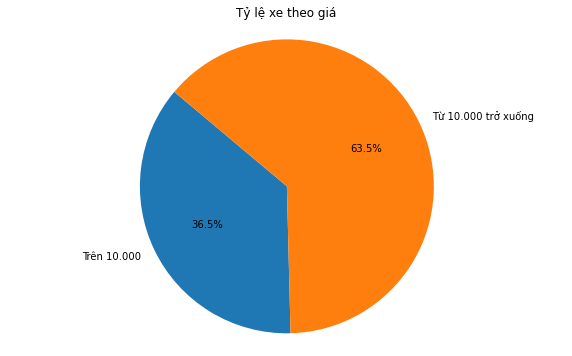

In [12]:
#cau 5 Cho biết tỷ lệ xe có giá trên 10.000? Chọn loại đồ thị phù hợp để so sánh trực
#quan tỷ lệ xe có giá trên 10.000 và tỷ lệ xe có giá từ 10.000 trở xuống.
price_above_10000 = len(data[data['Price'] > 10000])
price_below_or_equal_10000 = len(data[data['Price'] <= 10000])
total_cars = len(data)

print(f"\nTỷ lệ xe có giá trên 10.000: {price_above_10000/total_cars:.2%}")
print(f"Tỷ lệ xe có giá từ 10.000 trở xuống: {price_below_or_equal_10000/total_cars:.2%}")

# Đồ thị so sánh
labels = ['Trên 10.000', 'Từ 10.000 trở xuống']
sizes = [price_above_10000, price_below_or_equal_10000]

plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Tỷ lệ xe theo giá")
plt.axis('equal')
plt.show()


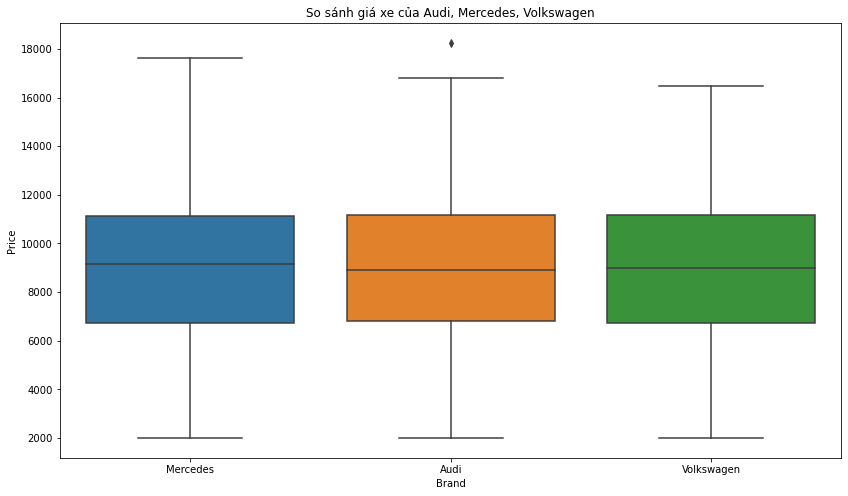

In [14]:
#cau 6 Hãy chọn đồ thị phù hợp để so sánh trực quan giá xe của 03 hãng xe Audi,
#Mercedes, Volkswagen.
selected_brands = ['Audi', 'Mercedes', 'Volkswagen']
selected_data = data[data['Brand'].isin(selected_brands)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='Brand', y='Price', data=selected_data)
plt.title("So sánh giá xe của Audi, Mercedes, Volkswagen")
plt.show()

In [16]:
#cau 7 Hãy đưa ra một số bình luận từ các số liệu thống kê thu được.
print("\nBình luận:")
print("1. Dữ liệu có nhiều hãng xe với các mẫu xe khác nhau.")
print("2. Giá xe có độ phân tán lớn, nhiều xe có giá trên 10.000 tuy nhiên cũng có nhiều xe giá từ 10.000 trở xuống.")
print("3. Trong 3 hãng Audi, Mercedes, Volkswagen có sự khác biệt đáng kể về giá giữa các hãng.")



Bình luận:
1. Dữ liệu có nhiều hãng xe với các mẫu xe khác nhau.
2. Giá xe có độ phân tán lớn, nhiều xe có giá trên 10.000 tuy nhiên cũng có nhiều xe giá từ 10.000 trở xuống.
3. Trong 3 hãng Audi, Mercedes, Volkswagen, có sự khác biệt đáng kể về giá giữa các hãng.
